# §3 Monte Carlo on combined (unfiltered) (v12)

IID bootstrap (10,000 sims) on the combined unfiltered trade stream.
Plots: bootstrap equity paths, final PnL histogram, annualized Sharpe
histogram, max-drawdown histogram — one of each per sizing policy.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v12.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v12.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 4,537
Loaded combos_ml2 from cache (10 combos).
ML2 portfolio trade counts: {'fixed_dollars_500': 0, 'pct5_compound': 0}


In [2]:
rows = []
for policy in POLICIES:
    if combined_raw.empty:
        rows.append({'policy': policy, 'n_trades': 0}); continue
    pnl_base = combined_raw['actual_pnl'].to_numpy(dtype=float)
    risk_base = combined_raw['dollar_risk'].to_numpy(dtype=float)
    rows.append({'policy': policy,
                 **monte_carlo(pnl_base, risk_base, policy, YEARS_SPAN)})
mc_raw = pd.DataFrame(rows)
mc_raw

,policy,n_sims,n_trades,win_rate,wr_ci_95,dd_p50_pct,dd_p90_pct,dd_p95_pct,dd_p99_pct,dd_worst_pct,...,dd_p95_dollars,dd_p99_dollars,dd_worst_dollars,var_5pct_trade,cvar_5pct_trade,risk_of_ruin_prob,trades_per_year,sharpe_p50,sharpe_ci_95,sharpe_pos_prob
0,fixed_dollars_500,10000,4537,0.2824,"(0.2691, 0.296)",34.56,63.69,76.13,106.15,206.02,...,56358.16,7.379950e+04,1.244972e+05,-477.81,-479.42,0.2153,3105.4,1.5970,"(-0.0447, 3.2014)",0.9721
1,pct5_compound,10000,4537,0.2824,"(0.2691, 0.296)",99.96,100.00,100.00,100.00,100.00,...,68760103.85,1.090442e+09,6.172262e+12,-48232.69,-37900898.85,1.0000,3105.4,-0.6124,"(-2.3142, 1.0199)",0.2331


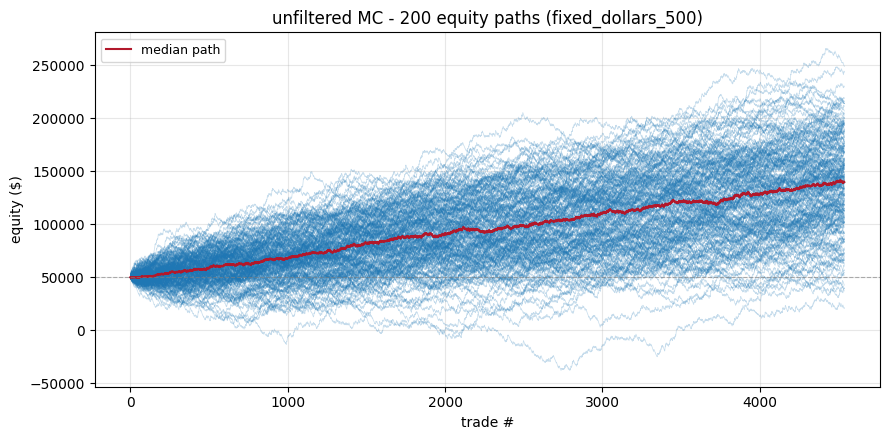

In [3]:
plot_mc_sims(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

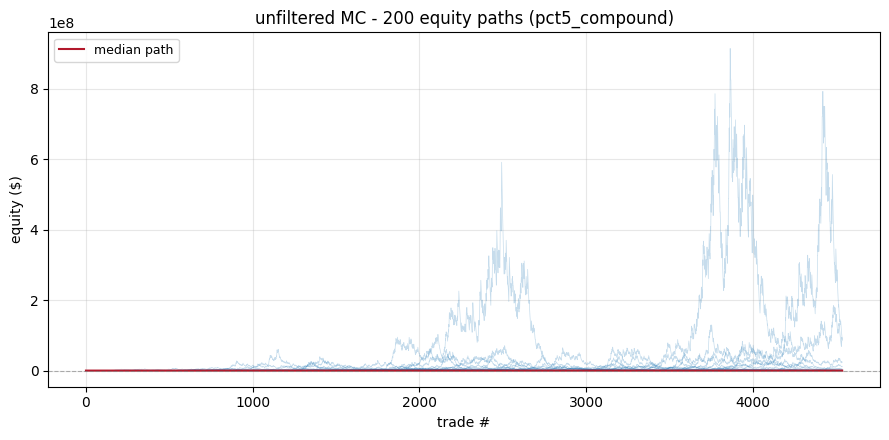

In [4]:
plot_mc_sims(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)

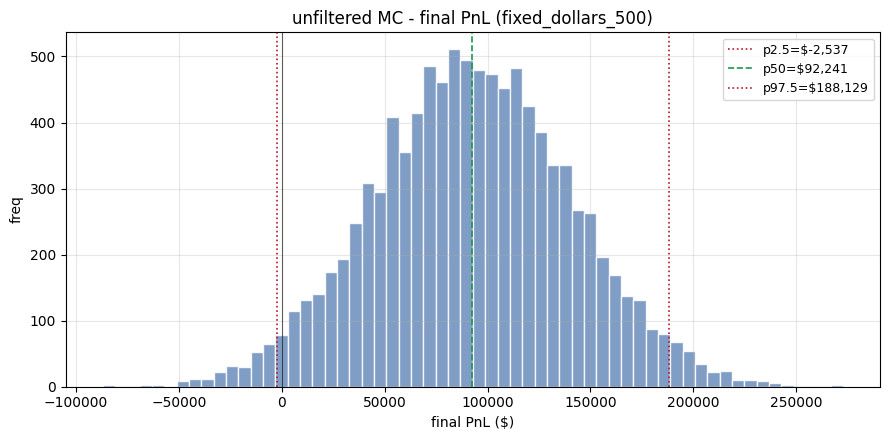

In [5]:
plot_mc_pnl(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

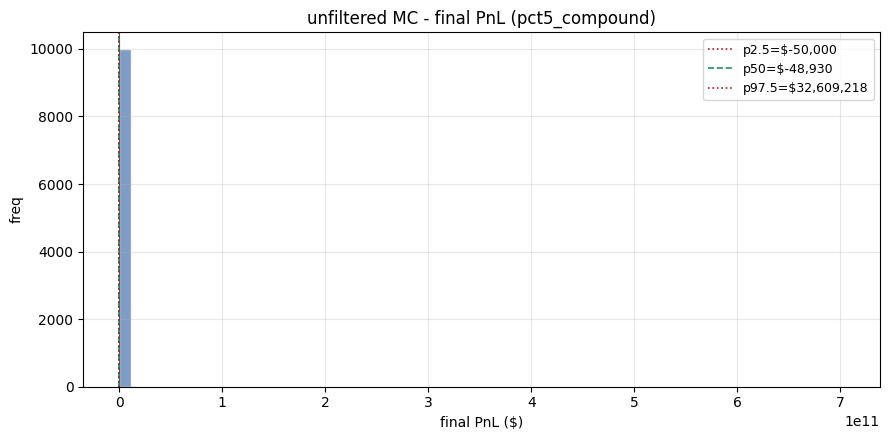

In [6]:
plot_mc_pnl(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)

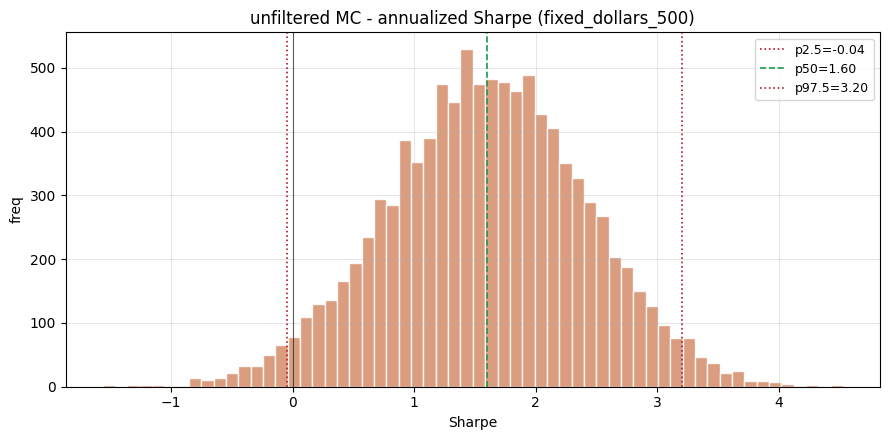

In [7]:
plot_mc_sharpe(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

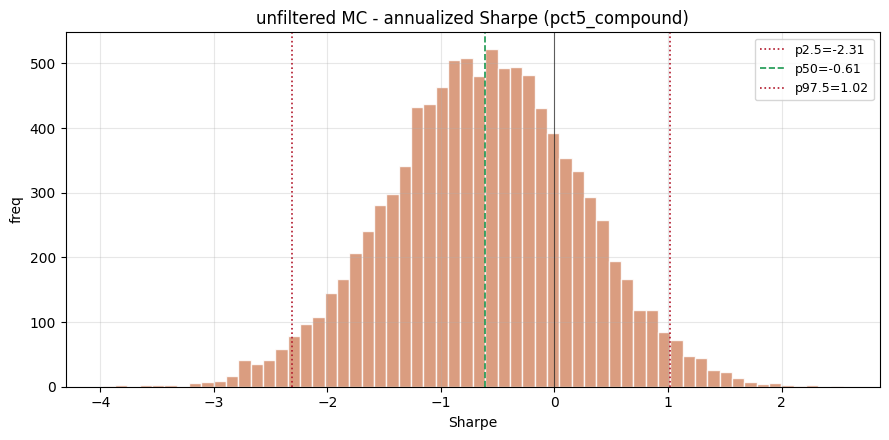

In [8]:
plot_mc_sharpe(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)

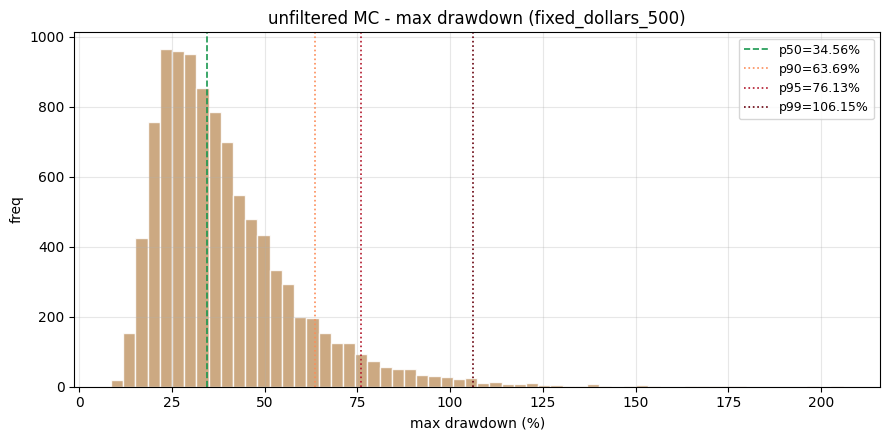

In [9]:
plot_mc_dd(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

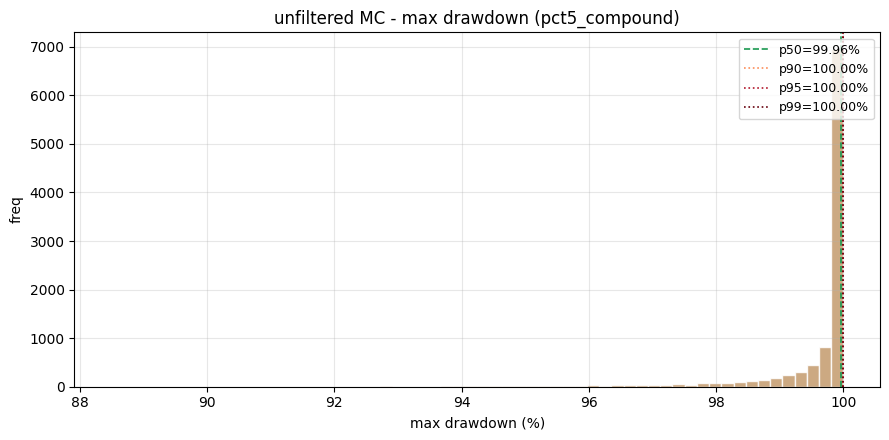

In [10]:
plot_mc_dd(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)